In [1]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

import os
from Frquencies_plot_func import plot_frequencies_aa_pos,plot_corr_aa_pos

from seq_utils import letters_to_nums, sequences_from_fasta, one_hot_seq_batch,extract_beta_beta_PCA
from PCA_func import plot_projected_pca, plot_pca_of_sequences, plot_two_pca_side_by_side, plot_projected_pca_mult,plot_projected_pca_time
import sys
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.insert(0, parent_dir)
from utils import read_fasta_alignment, remove_duplicate_sequences,extract_sequences_around_PCA,quickread
from hamming_dist import hamming_dist, energy_corr_array

import matplotlib
matplotlib.rc('xtick', labelsize=15) 
matplotlib.rc('ytick', labelsize=15)
font = {'size'   : 16}
from scipy.stats import linregress
family = 'jdoms_bacteria_train2'
file_test_data=r"C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main\CODE\DataAttentionDCA\jdoms\jdoms_bacteria_train2.fasta"
_,W=quickread(file_test_data)
W=W/W.sum()

def plot_decorrelation(correlation,range,save_path=None):
    x_vals = np.arange(range)  # X values for linear fit (steps)
    y_vals = correlation[:range]  # First 1000 correlation values
    
    # Perform linear fit: y = mx + c, extract the slope (m)
    #slope, intercept, r_value, p_value, std_err = linregress(x_vals, np.exp(y_vals))
    
    # Store the slope for this beta
    
    
    # Plot the correlation curve and linear fit
    plt.plot(correlation, marker='', linestyle='-', linewidth=1, label="Correlation")
    #plt.plot(np.arange(len(correlation)), np.exp(slope * np.arange(len(correlation))), color='r',linestyle="--", label=f"Fit: rate = {slope:.2e}")
    plt.xlabel("Correlation Step")
    plt.ylabel("Correlation")
    plt.legend()
    plt.grid(True)
    if save_path:
        plt.savefig(save_path)
    plt.show()

Total sequences read: 14502
Sequences after filtering: 14502
Sampling 100000 pairs out of 105146751 total pairs.
Mean fraction of identical positions (sampled): 0.37195492063492064
Computed theta: 0.3269213371137311


100%|██████████| 14502/14502 [00:12<00:00, 1133.41it/s]

3265.70225762244



Processing file: gill_gen_seqs_randinit_Ns8000_b_1_b_PCA10_PCA_comp_24_20PCA_comp.npy


C:\Users\youss\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


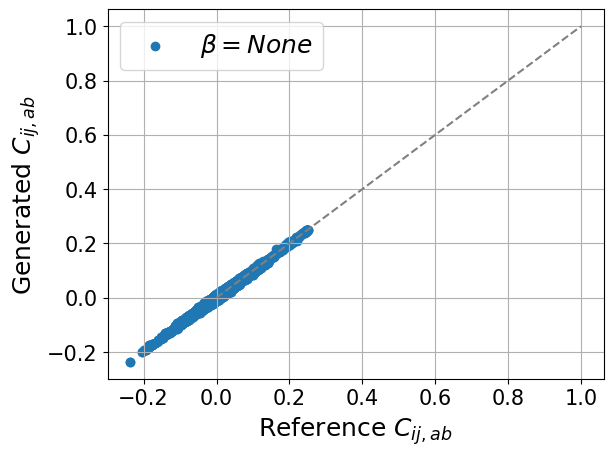

NameError: name 'filename' is not defined

In [ ]:
# ----- Paths -----
generated_dir = 'gill_gen_PCA_brute_force_good'
cwd = os.getcwd()
full_gen_path = os.path.join(cwd, generated_dir)

# ----- Load train sequences -----
family = 'jdoms_bacteria_train2'
file_test_data=r"C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main\CODE\DataAttentionDCA\jdoms\jdoms_bacteria_train2.fasta"

train_sequences = sequences_from_fasta(file_test_data)
train_sequences_num = [letters_to_nums(seq) for seq in train_sequences]

save_path = os.path.join(cwd, 'results', 'good_PCA_GEN_figures_gillespie')
os.makedirs(save_path, exist_ok=True)

# ----- Loop through all .npy files in directory -----
for file in os.listdir(full_gen_path):
    if file.endswith('.npy'):
        beta, beta_PCA=extract_beta_beta_PCA(file)
        print(f"\nProcessing file: {file}")
        
        # Load generated sequences
        file_path = os.path.join(full_gen_path, file)
        gen_sequences = np.load(file_path)
        L=63
        if gen_sequences.shape[1] > L:
            target_coords = gen_sequences[0, -2:]  # Last two columns are PCA coords
            gen_sequences = gen_sequences[:, :-2]  # Remove last 2 cols if they are PCA coords
        else:
            target_coords = None
        # Optional: slice if needed
        # gen_sequences = gen_sequences[Ni:Nf]  # Uncomment if you want to subset

        # Extract target PCA coordinates from filename
        #match = re.findall(r'\d+\.\d+|\d+', file)  # Captures floats or ints
        #if len(match) >= 2:
        #    target_coords = np.array([float(match[-2]), float(match[-1])])
        #else:
        #    print("Warning: Could not extract PCA coords from filename.")
        #    target_coords = None
#
        # Plot PCA projection
        title = f"PCA Projection: {file}"
        plot_projected_pca_time(
            sequences_reference=train_sequences,
            sequences_to_project=gen_sequences,
            title=title,
            Nbins=35,
            target_coords=target_coords,save_path=save_path+file+".png")
        filename=file
        plot_frequencies_aa_pos(gen_sequences[1000::200],np.array(train_sequences_num),save_path=save_path,filename=filename,beta=beta,beta_PCA=beta_PCA)
        plot_corr_aa_pos(np.array(train_sequences_num[::4]),np.array(train_sequences_num[1::4]))
        local_train_sequences=extract_sequences_around_PCA(np.array(train_sequences_num),target_coords,35,7,W=W)
        print(local_train_sequences.shape)
        filename=filename+"local_target"
        plot_frequencies_aa_pos(gen_sequences[1000::200],local_train_sequences,save_path=save_path,filename=filename,beta=beta,beta_PCA=beta_PCA)
        



Processing file: gen_seqs_randinit_Ns150000_b_1_b_PCA10_PCA_comp_24_20PCA_comp.npy

Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA0.5_PCA_comp_24_20PCA_comp.npy

Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA10_PCA_comp_24_20PCA_comp copy.npy

Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA10_PCA_comp_24_20PCA_comp.npy

Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA10_PCA_comp_27_5PCA_comp.npy

Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA10_PCA_comp_8_8PCA_comp.npy

Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA1_PCA_comp_24_20PCA_comp.npy

Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA20_PCA_comp_24_20PCA_comp.npy

Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA20_PCA_comp_27_5PCA_comp.npy

Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA20_PCA_comp_8_8PCA_comp.npy

Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA2_PCA_comp_24_20PCA_comp.npy

Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA4_PCA_comp_24_20PCA_comp.npy

Proce

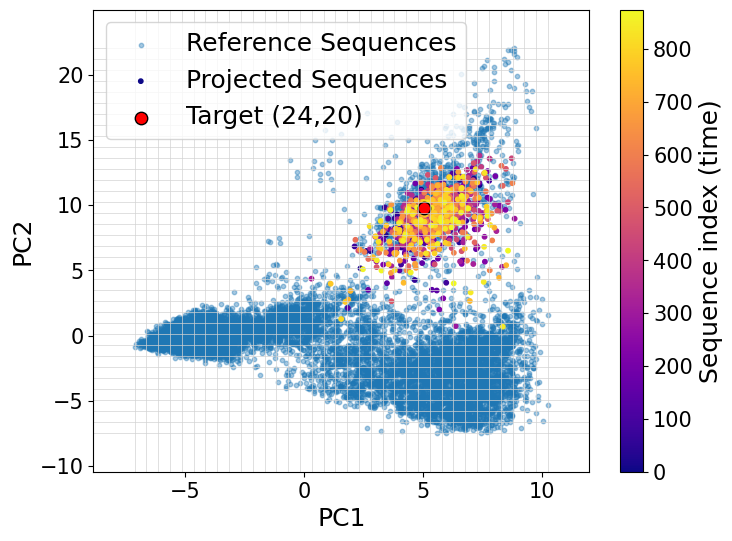

test 1


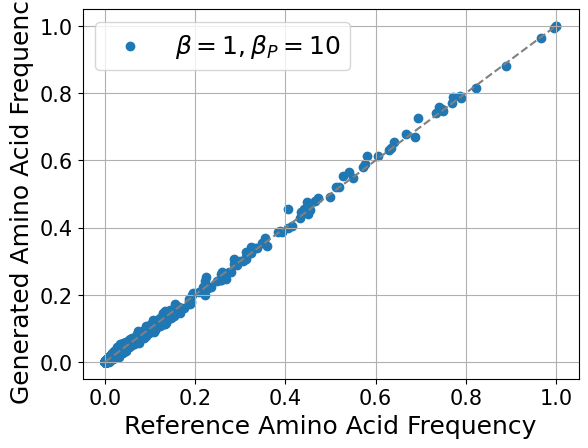

C:\Users\youss\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


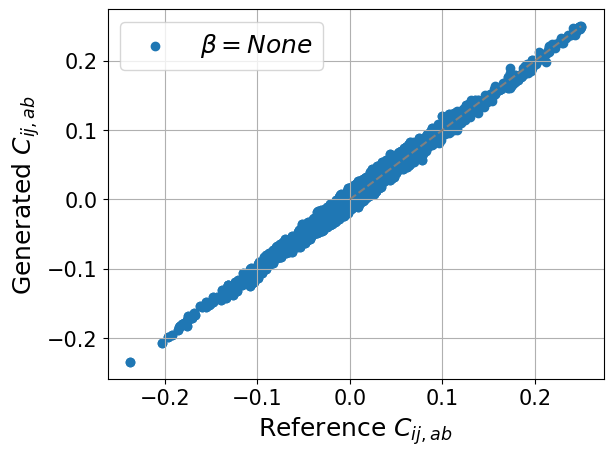

In [4]:
# ----- Paths -----
generated_dir = 'plm_gen_PCA_brute_force_good'
cwd = os.getcwd()
full_gen_path = os.path.join(cwd, generated_dir)

# ----- Load train sequences -----
family = 'jdoms_bacteria_train2'
file_test_data=r"C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main\CODE\DataAttentionDCA\jdoms\jdoms_bacteria_train2.fasta"

train_sequences = sequences_from_fasta(file_test_data)
train_sequences_num = [letters_to_nums(seq) for seq in train_sequences]

save_path = os.path.join(cwd, 'results', 'good_PCA_GEN_figures_plm')
os.makedirs(save_path, exist_ok=True)

# ----- Loop through all .npy files in directory -----
for file in os.listdir(full_gen_path):
    if file.endswith('.npy'):
        
        print(f"\nProcessing file: {file}")
        beta, beta_PCA=extract_beta_beta_PCA(file)
        # Load generated sequences
        file_path = os.path.join(full_gen_path, file)
        gen_sequences = np.load(file_path)
        L=63
        if gen_sequences.shape[1] > L:
            target_coords = gen_sequences[0, -2:]  # Last two columns are PCA coords
            gen_sequences = gen_sequences[:, :-2]  # Remove last 2 cols if they are PCA coords
        else:
            target_coords = None
        # Optional: slice if needed
        # gen_sequences = gen_sequences[Ni:Nf]  # Uncomment if you want to subset

        # Extract target PCA coordinates from filename
        #match = re.findall(r'\d+\.\d+|\d+', file)  # Captures floats or ints
        #if len(match) >= 2:
        #    target_coords = np.array([float(match[-2]), float(match[-1])])
        #else:
        #    print("Warning: Could not extract PCA coords from filename.")
        #    target_coords = None
#
        # Plot PCA projection
        title = f"PCA Projection: {file}"
        if file=="gen_seqs_randinit_Ns500000_b_1_b_PCA10_PCA_comp_24_20PCA_comp.npy":
            initial_sequence = gen_sequences[0]
            hamming_distances = []
            for seq in gen_sequences:
                distance = hamming_dist(initial_sequence, seq)
                hamming_distances.append(distance)
            hamming_distances = np.array(hamming_distances)
            #correlation = energy_corr_array(hamming_distances, int(len(hamming_distances)/5))
            range=300
            #plot_decorrelation(correlation[:2000],range)
            plot_projected_pca_time(
                sequences_reference=train_sequences,
                sequences_to_project=gen_sequences[::400],
                title=title,
                Nbins=35,
                target_coords=target_coords,save_path=save_path+"/"+file+".png")
            filename=file
            
            #plot_frequencies_aa_pos(gen_sequences[1000::500],np.array(train_sequences_num[::2]),save_path=save_path,filename=filename,beta=beta,beta_PCA=beta_PCA)
            print("test 1")
            plot_frequencies_aa_pos(np.array(train_sequences_num[1:1000]),np.array(train_sequences_num[1000:]),save_path=save_path,filename=filename,beta=beta,beta_PCA=beta_PCA)
            plot_corr_aa_pos(np.array(train_sequences_num[1:1000]),np.array(train_sequences_num[1000:]))
            #plot_corr_aa_pos(gen_sequences[1000::500],np.array(train_sequences_num))

            #local_train_sequences=extract_sequences_around_PCA(np.array(train_sequences_num),target_coords,35,7)
            #print(local_train_sequences.shape)
            filename=filename+"local_target"
            #plot_corr_aa_pos(gen_sequences[1000::500],np.array(local_train_sequences))
            #plot_frequencies_aa_pos(gen_sequences[1000::500],local_train_sequences,save_path=save_path,filename=filename,beta=beta,beta_PCA=beta_PCA)
            



Processing file: gen_vect_plm_randinit_n_iter1500_nb_seq10000_b_PCA_10_PCA24_20PCA_comp.npy


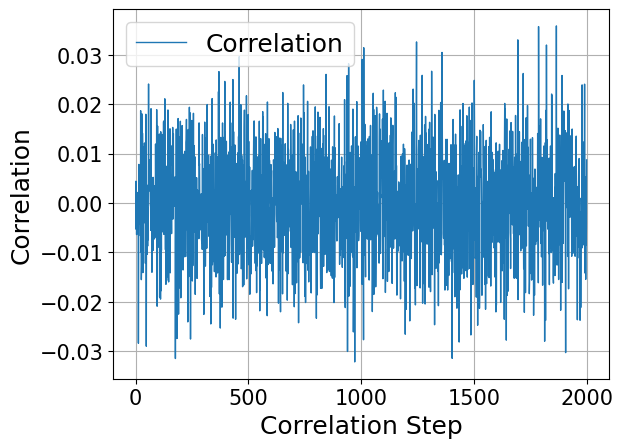

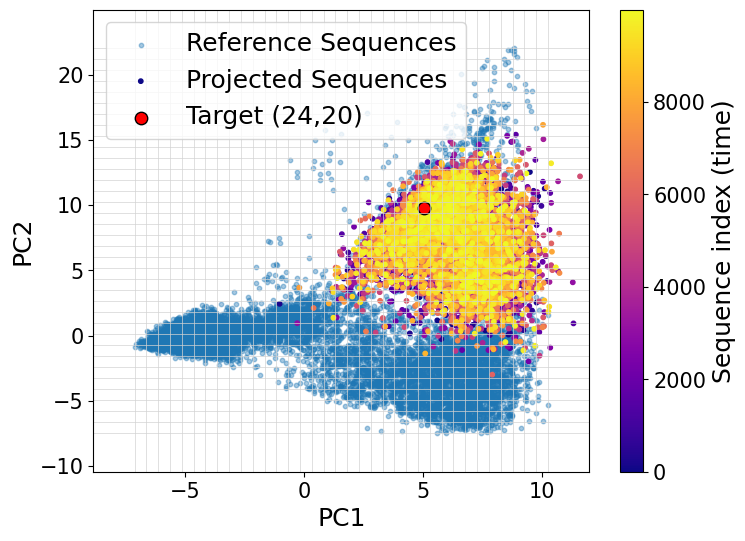

[0.         0.         0.32025499 ... 0.         0.         0.63877448]


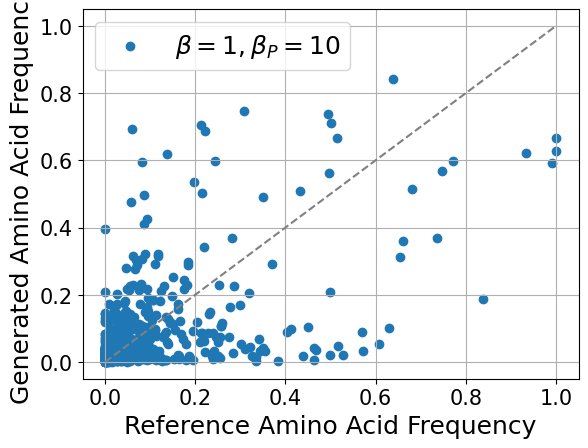

(14502, 65)
(14502,)
(970, 63)
[0.         0.         0.205996   ... 0.         0.         0.96934445]


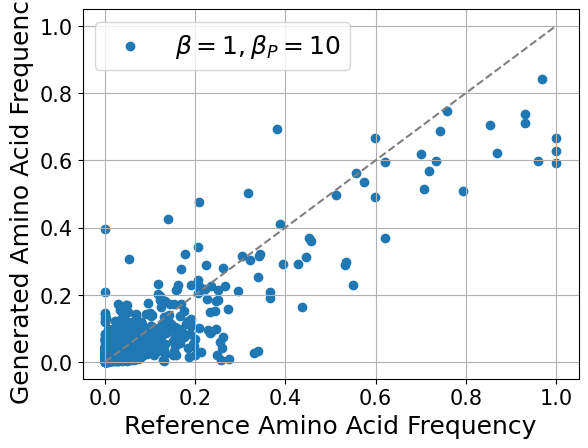


Processing file: gen_vect_plm_randinit_n_iter1500_nb_seq10000_b_PCA_15_b_1_5_PCA24_20PCA_comp.npy


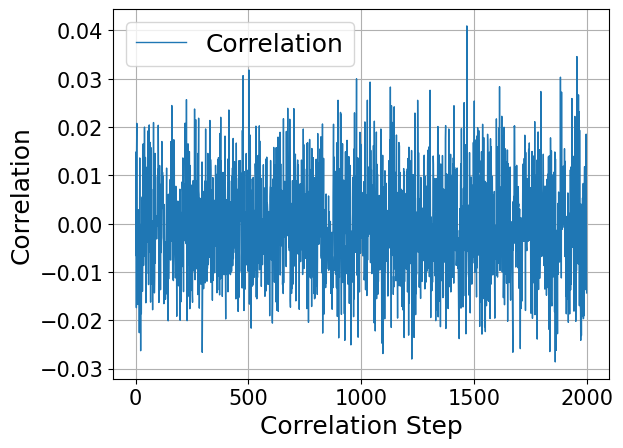

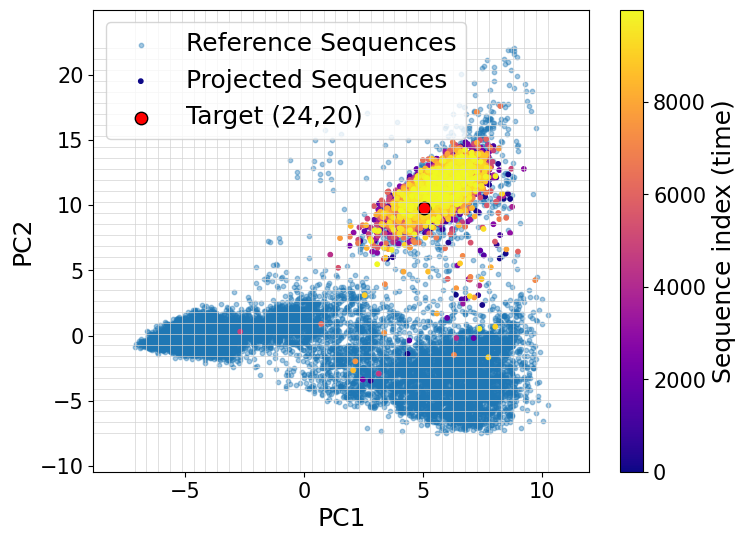

[0.         0.         0.32025499 ... 0.         0.         0.63877448]


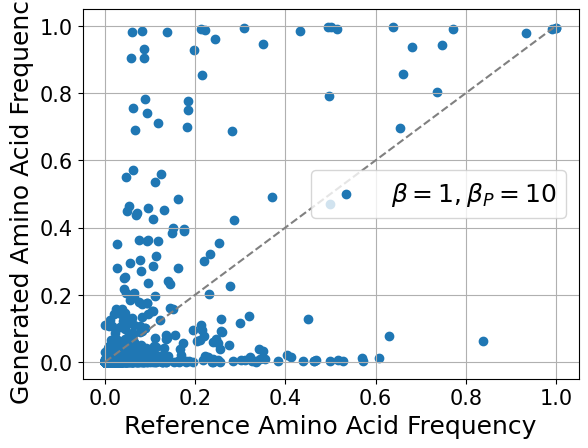

(14502, 65)
(14502,)
(970, 63)
[0.         0.         0.205996   ... 0.         0.         0.96934445]


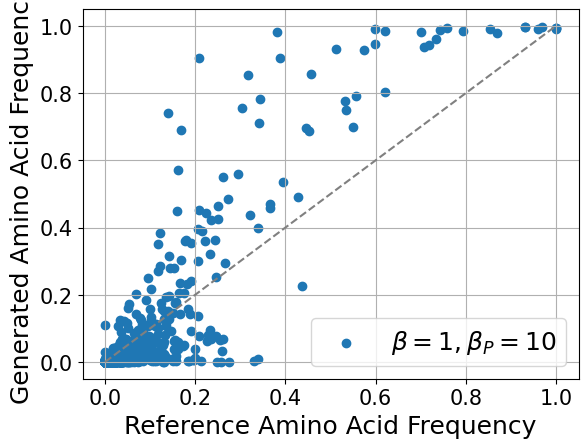


Processing file: gen_vect_plm_randinit_n_iter1500_nb_seq10000_b_PCA_15_b_2_PCA24_20PCA_comp.npy


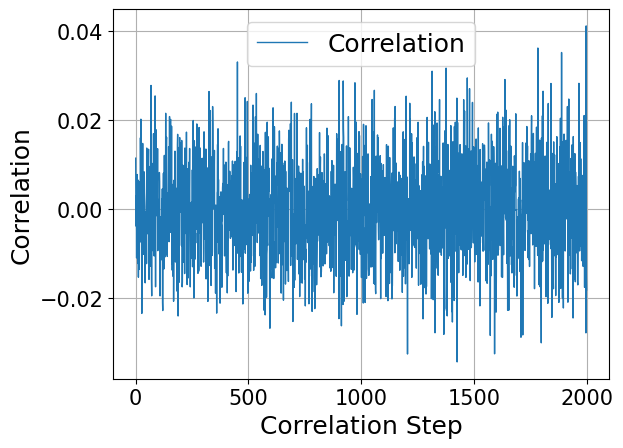

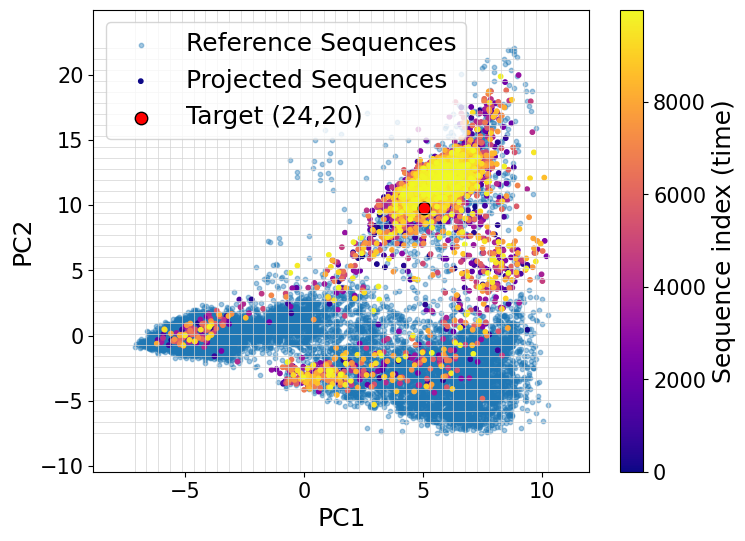

[0.         0.         0.32025499 ... 0.         0.         0.63877448]


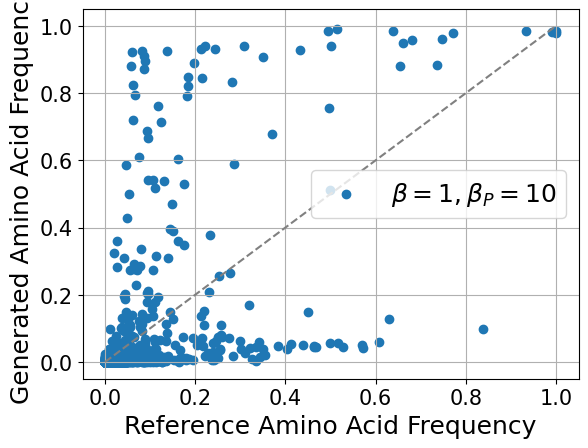

(14502, 65)
(14502,)
(970, 63)
[0.         0.         0.205996   ... 0.         0.         0.96934445]


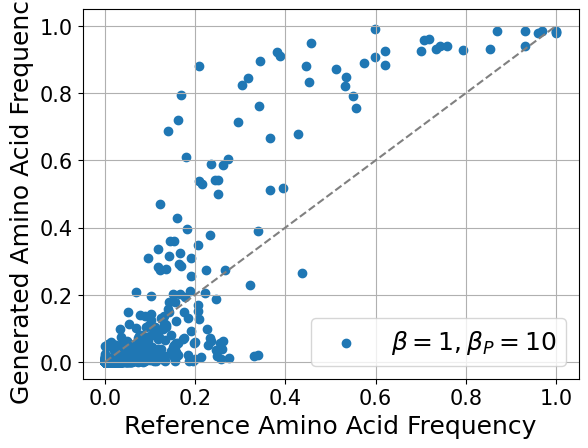


Processing file: gen_vect_plm_randinit_n_iter1500_nb_seq10000_b_PCA_7_PCA24_20PCA_comp.npy


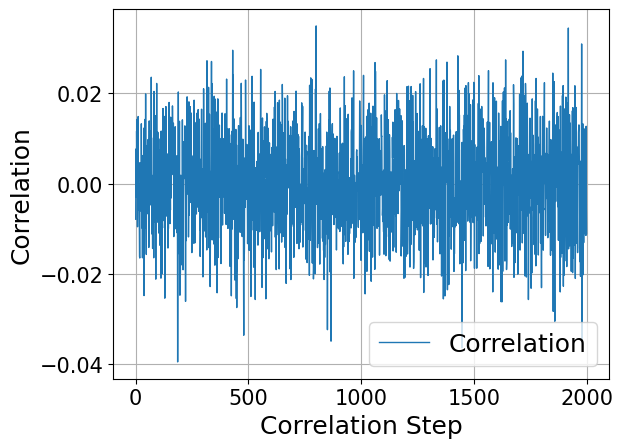

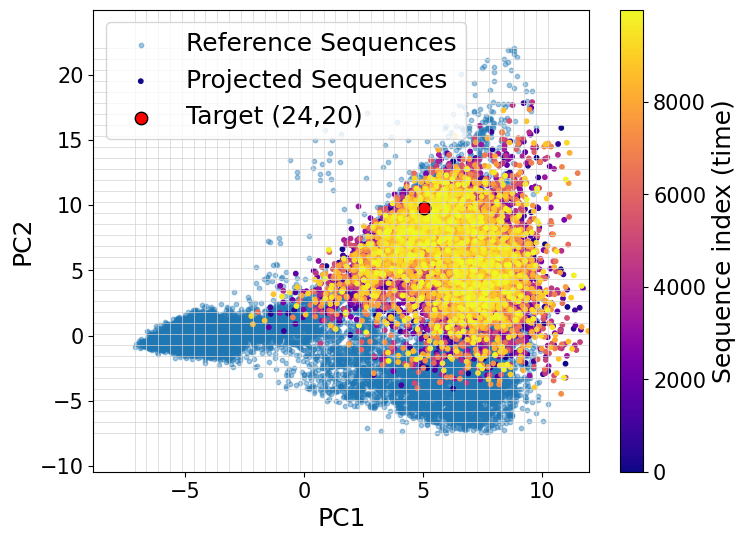

[0.         0.         0.32025499 ... 0.         0.         0.63877448]


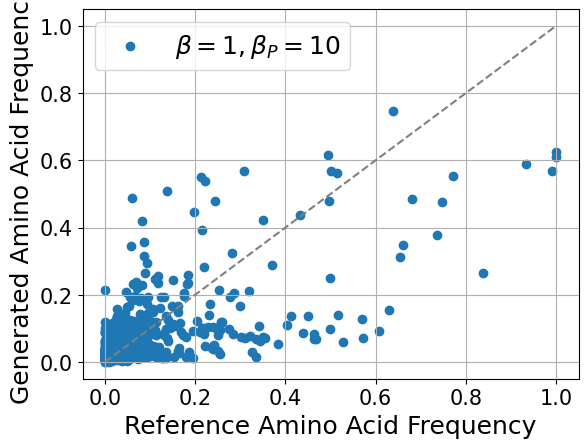

(14502, 65)
(14502,)
(970, 63)
[0.         0.         0.205996   ... 0.         0.         0.96934445]


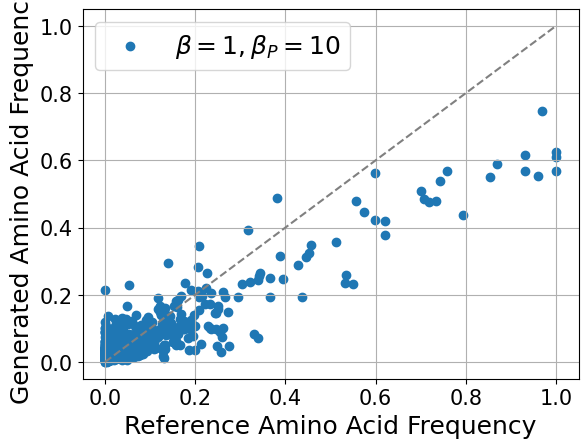


Processing file: gen_vect_plm_randinit_n_iter1500_nb_seq3000_b_PCA_10_PCA24_20PCA_comp.npy


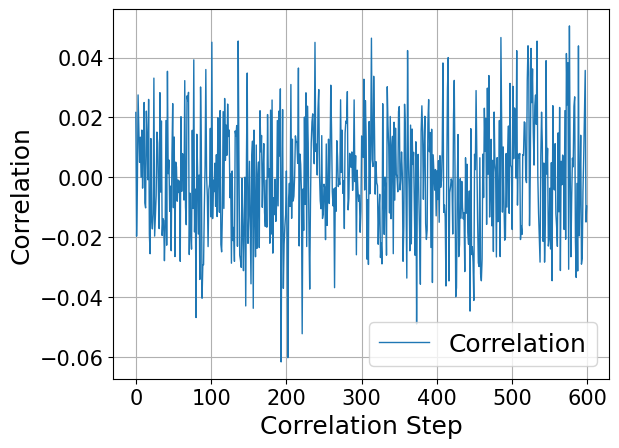

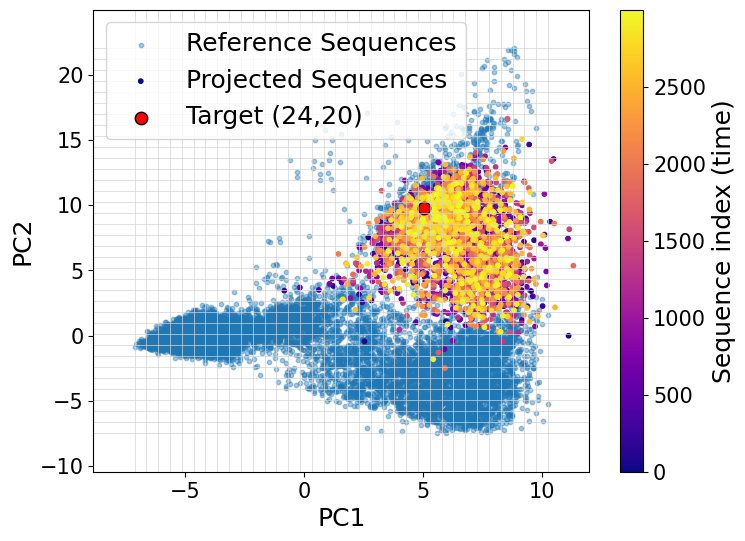

[0.         0.         0.32025499 ... 0.         0.         0.63877448]


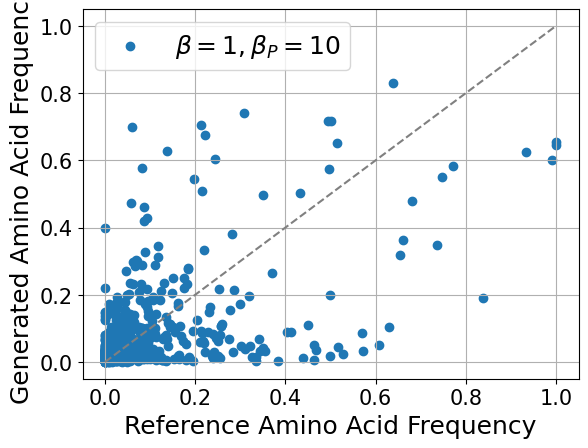

(14502, 65)
(14502,)
(970, 63)
[0.         0.         0.205996   ... 0.         0.         0.96934445]


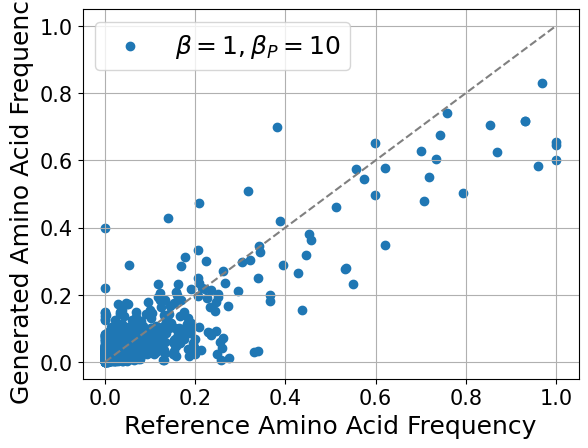

In [6]:
# ----- Paths -----
generated_dir = 'generated_vect_sequences_brute_forcePCA_comp'
cwd = os.getcwd()
full_gen_path = os.path.join(cwd,'Sequences' ,generated_dir)

# ----- Load train sequences -----
family = 'jdoms_bacteria_train2'
file_test_data=r"C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main\CODE\DataAttentionDCA\jdoms\jdoms_bacteria_train2.fasta"

train_sequences = sequences_from_fasta(file_test_data)
train_sequences_num = [letters_to_nums(seq) for seq in train_sequences]

save_path = os.path.join(cwd, 'results', 'good_PCA_GEN_figures_gillespie')
os.makedirs(save_path, exist_ok=True)
# ----- Loop through all .npy files in directory -----
for file in os.listdir(full_gen_path):
    if file.endswith('.npy'):
        beta, beta_PCA=1,10
        print(f"\nProcessing file: {file}")
        
        # Load generated sequences
        file_path = os.path.join(full_gen_path, file)
        gen_sequences = np.load(file_path)
        L=63
        initial_sequence = gen_sequences[0]
        hamming_distances = []
        for seq in gen_sequences:
            distance = hamming_dist(initial_sequence, seq)
            hamming_distances.append(distance)
        hamming_distances = np.array(hamming_distances)
        correlation = energy_corr_array(hamming_distances, int(len(hamming_distances)/5))
        range=300
        plot_decorrelation(correlation,range)
        if gen_sequences.shape[1] > L:
            target_coords = gen_sequences[0, -2:]  # Last two columns are PCA coords
            gen_sequences = gen_sequences[:, :-2]  # Remove last 2 cols if they are PCA coords
        else:
            target_coords = None
        # Optional: slice if needed
        # gen_sequences = gen_sequences[Ni:Nf]  # Uncomment if you want to subset

        # Extract target PCA coordinates from filename
        #match = re.findall(r'\d+\.\d+|\d+', file)  # Captures floats or ints
        #if len(match) >= 2:
        #    target_coords = np.array([float(match[-2]), float(match[-1])])
        #else:
        #    print("Warning: Could not extract PCA coords from filename.")
        #    target_coords = None
#
        # Plot PCA projection
        title = f"PCA Projection: {file}"
        plot_projected_pca_time(
            sequences_reference=train_sequences,
            sequences_to_project=gen_sequences,
            title=title,
            Nbins=35,
            target_coords=target_coords,save_path=save_path+file+".png")
        filename=file
        plot_frequencies_aa_pos(gen_sequences,np.array(train_sequences_num),save_path=save_path,filename=filename,beta=beta,beta_PCA=beta_PCA,W=W)
        #plot_corr_aa_pos(gen_sequences,np.array(train_sequences_num),W=W)
        local_train_sequences,W_local=extract_sequences_around_PCA(np.array(train_sequences_num),target_coords,35,7,W=W)
        W_local=W_local/W_local.sum()
        print(local_train_sequences.shape)
        filename=filename+"local_target"
        plot_frequencies_aa_pos(gen_sequences,local_train_sequences,save_path=save_path,filename=filename,beta=beta,beta_PCA=beta_PCA,W=W_local)
        #plot_corr_aa_pos(gen_sequences,local_train_sequences,W=W_local)



Processing file: Nbins35_gen_2000_2000_1.2_13_14_12PCA_comp.npy

Processing file: Nbins35_gen_2000_2000_1.2_13_24_20PCA_comp.npy


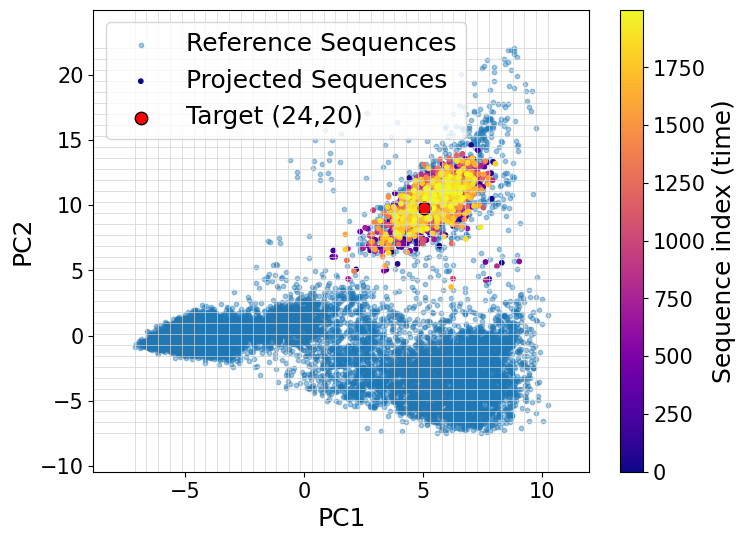

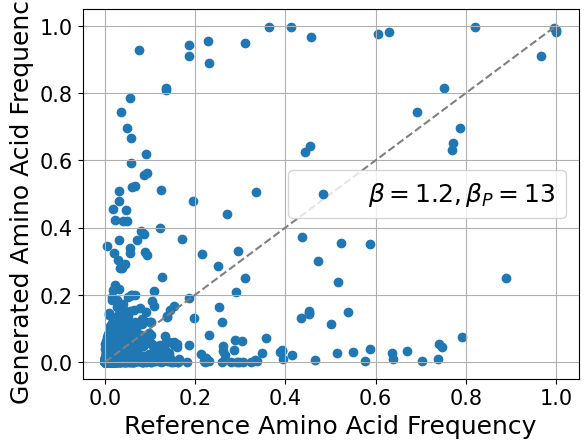

test 1
(14502, 65)
(14502,)


C:\Users\youss\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


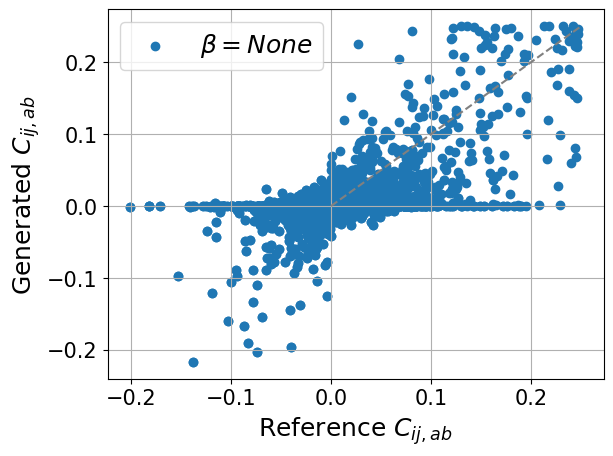

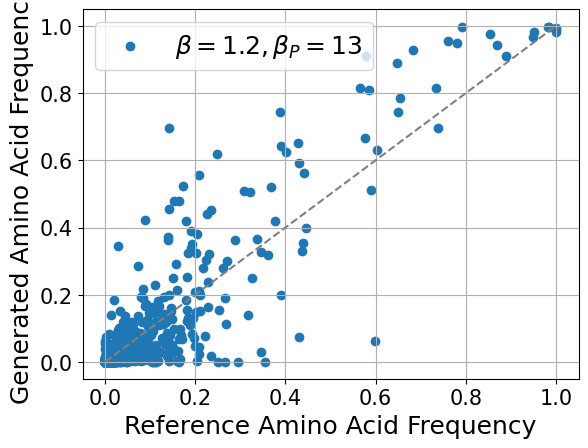


Processing file: Nbins35_gen_2000_2000_1.2_13_27_5PCA_comp.npy

Processing file: Nbins35_gen_2000_2000_1.2_13_8_8PCA_comp.npy


In [5]:
# ----- Paths -----
generated_dir = 'Jcond_methodPCA_comp'
cwd = os.getcwd()
full_gen_path = os.path.join(cwd, generated_dir)

# ----- Load train sequences -----
family = 'jdoms_bacteria_train2'
file_test_data=r"C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main\CODE\DataAttentionDCA\jdoms\jdoms_bacteria_train2.fasta"

train_sequences = sequences_from_fasta(file_test_data)
train_sequences_num = [letters_to_nums(seq) for seq in train_sequences]

save_path = os.path.join(cwd, 'results', 'good_PCA_GEN_figures_plm')
os.makedirs(save_path, exist_ok=True)

# ----- Loop through all .npy files in directory -----
for file in os.listdir(full_gen_path):
    if file.endswith('.npy') and file.startswith('Nbins35'):
        
        print(f"\nProcessing file: {file}")
        beta, beta_PCA=1.2,13
        # Load generated sequences
        file_path = os.path.join(full_gen_path, file)
        gen_sequences = np.load(file_path)
        L=63
        if gen_sequences.shape[1] > L:
            target_coords = gen_sequences[0, -2:]  # Last two columns are PCA coords
            gen_sequences = gen_sequences[:, :-2]  # Remove last 2 cols if they are PCA coords
        else:
            target_coords = None
        # Optional: slice if needed
        # gen_sequences = gen_sequences[Ni:Nf]  # Uncomment if you want to subset

        # Extract target PCA coordinates from filename
        #match = re.findall(r'\d+\.\d+|\d+', file)  # Captures floats or ints
        #if len(match) >= 2:
        #    target_coords = np.array([float(match[-2]), float(match[-1])])
        #else:
        #    print("Warning: Could not extract PCA coords from filename.")
        #    target_coords = None
#
        # Plot PCA projection
        title = f"PCA Projection: {file}"
        if file=="Nbins35_gen_2000_2000_1.2_13_24_20PCA_comp.npy":
            initial_sequence = gen_sequences[0]
            hamming_distances = []
            for seq in gen_sequences:
                distance = hamming_dist(initial_sequence, seq)
                hamming_distances.append(distance)
            hamming_distances = np.array(hamming_distances)
            #correlation = energy_corr_array(hamming_distances, int(len(hamming_distances)/5))
            range=300
            #plot_decorrelation(correlation[:2000],range)
            plot_projected_pca_time(
                sequences_reference=train_sequences,
                sequences_to_project=gen_sequences,
                title=title,
                Nbins=35,
                target_coords=target_coords,save_path=save_path+"/"+file+".png")
            filename=file
            
            plot_frequencies_aa_pos(gen_sequences,np.array(train_sequences_num[::2]),save_path=save_path,filename=filename,beta=beta,beta_PCA=beta_PCA)
            print("test 1")
            #plot_frequencies_aa_pos(np.array(train_sequences_num[1:1000]),np.array(train_sequences_num[1000:]),save_path=save_path,filename=filename,beta=beta,beta_PCA=beta_PCA)
            #plot_corr_aa_pos(np.array(train_sequences_num[1:1000]),np.array(train_sequences_num[1000:]))
            #plot_corr_aa_pos(gen_sequences[1000::500],np.array(train_sequences_num))

            local_train_sequences=extract_sequences_around_PCA(np.array(train_sequences_num),target_coords,35,7)
            #print(local_train_sequences.shape)
            filename=filename+"local_target"
            # plot_projected_pca_time(
            #     sequences_reference=train_sequences,
            #     sequences_to_project=local_train_sequences,
            #     title=title,
            #     Nbins=35,
            #     target_coords=target_coords)
            plot_corr_aa_pos(gen_sequences,np.array(local_train_sequences))
            plot_frequencies_aa_pos(gen_sequences,local_train_sequences,save_path=save_path,filename=filename,beta=beta,beta_PCA=beta_PCA)
            



Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA10_PCA_comp_24_20PCA_comp.npy


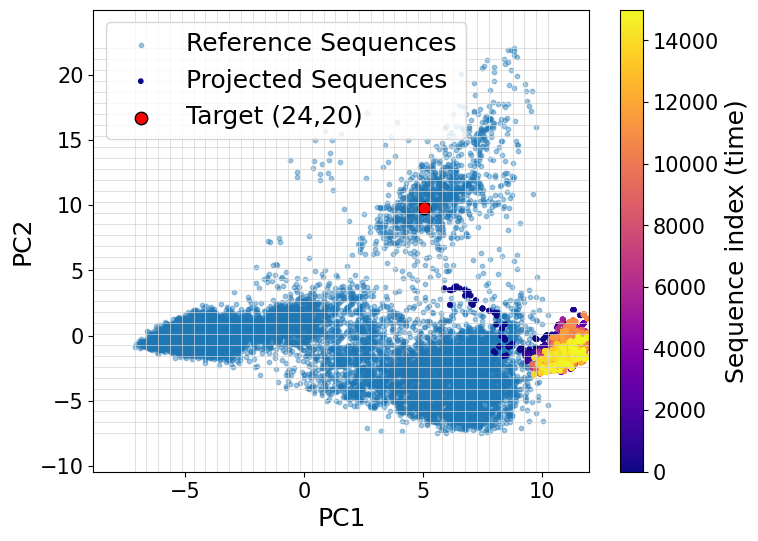

(14502, 65)
(14502,)
(970, 63)

Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA10_PCA_comp_27_5PCA_comp.npy


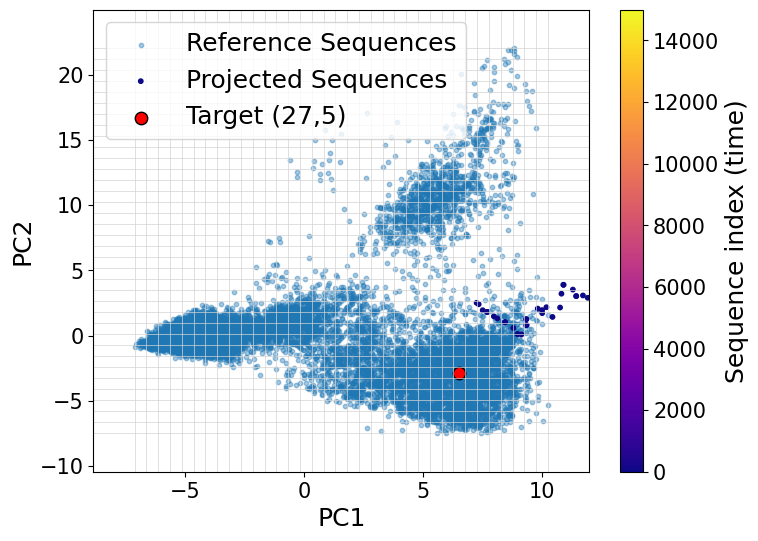

(14502, 65)
(14502,)
(3840, 63)

Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA10_PCA_comp_8_8PCA_comp.npy


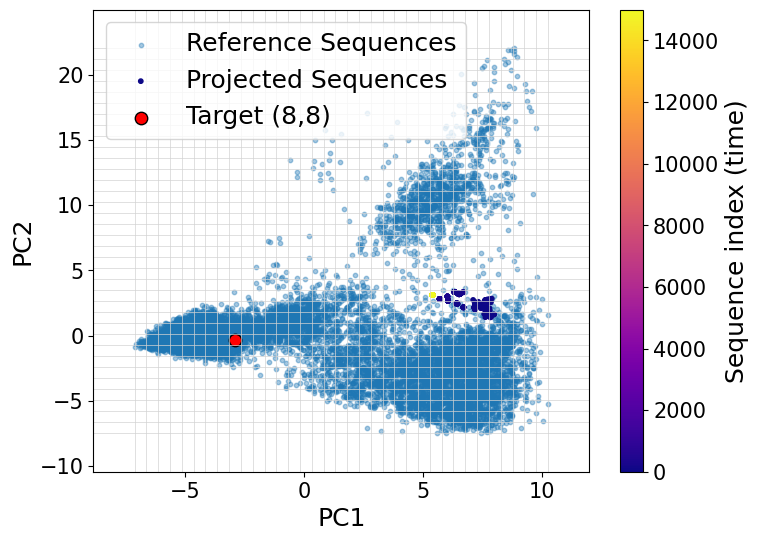

(14502, 65)
(14502,)
(7914, 63)

Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA15_PCA_comp_24_20PCA_comp.npy


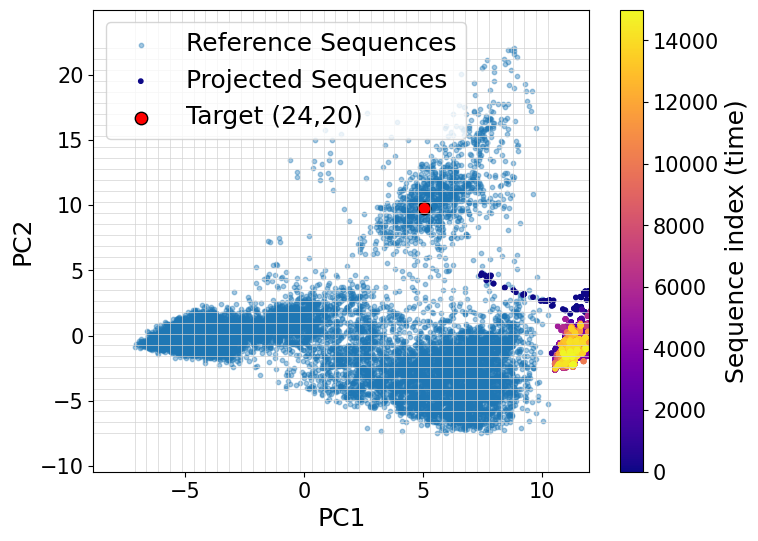

(14502, 65)
(14502,)
(970, 63)

Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA15_PCA_comp_27_5PCA_comp.npy


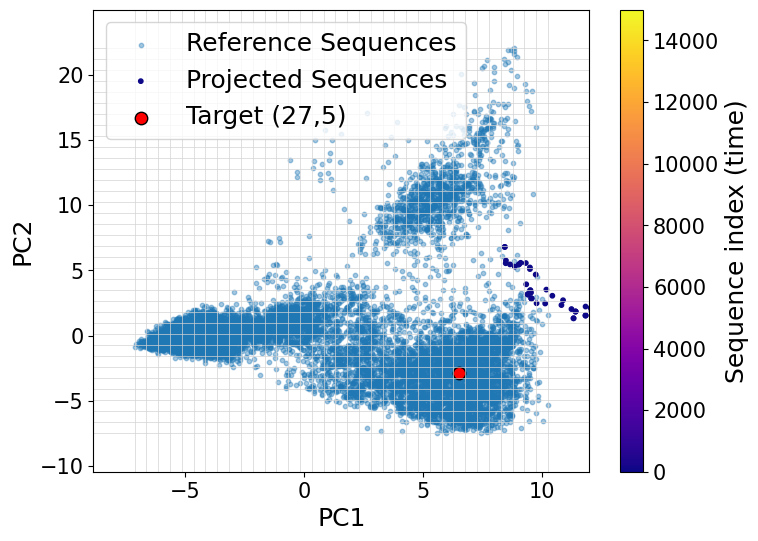

(14502, 65)
(14502,)
(3840, 63)

Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA15_PCA_comp_8_8PCA_comp.npy


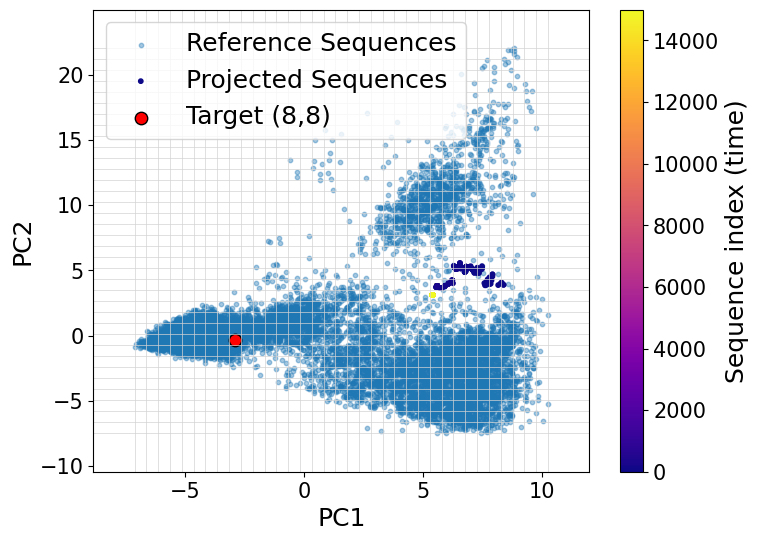

(14502, 65)
(14502,)
(7914, 63)

Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA25_PCA_comp_24_20PCA_comp.npy


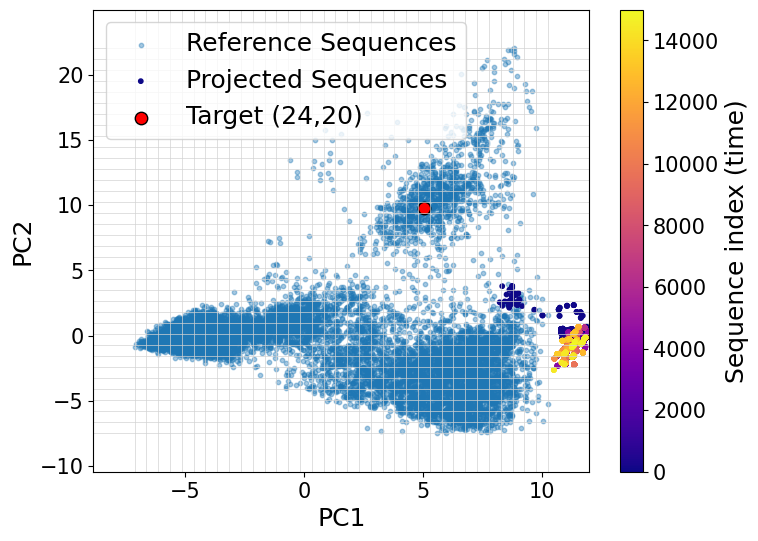

(14502, 65)
(14502,)
(970, 63)

Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA25_PCA_comp_27_5PCA_comp.npy


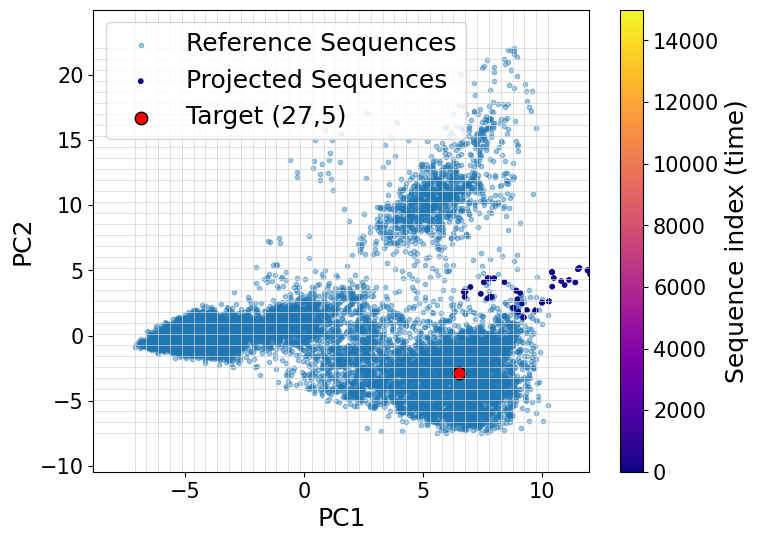

(14502, 65)
(14502,)
(3840, 63)

Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA25_PCA_comp_8_8PCA_comp.npy


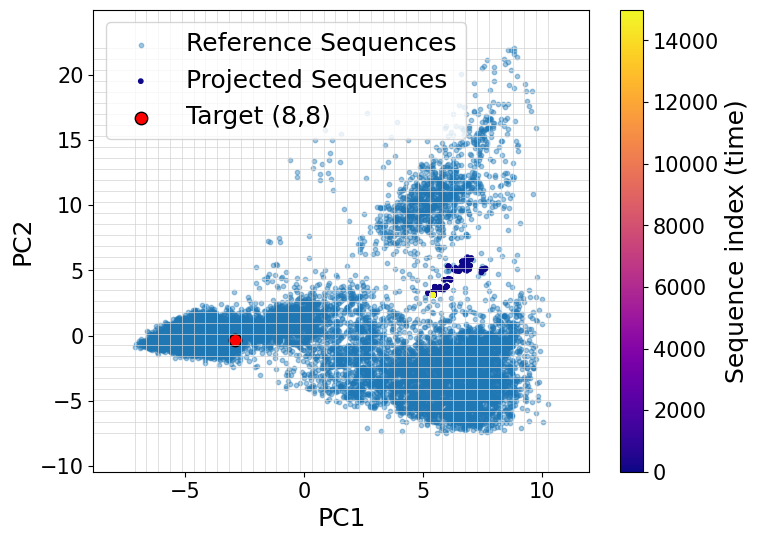

(14502, 65)
(14502,)
(7914, 63)

Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA6_PCA_comp_24_20PCA_comp.npy


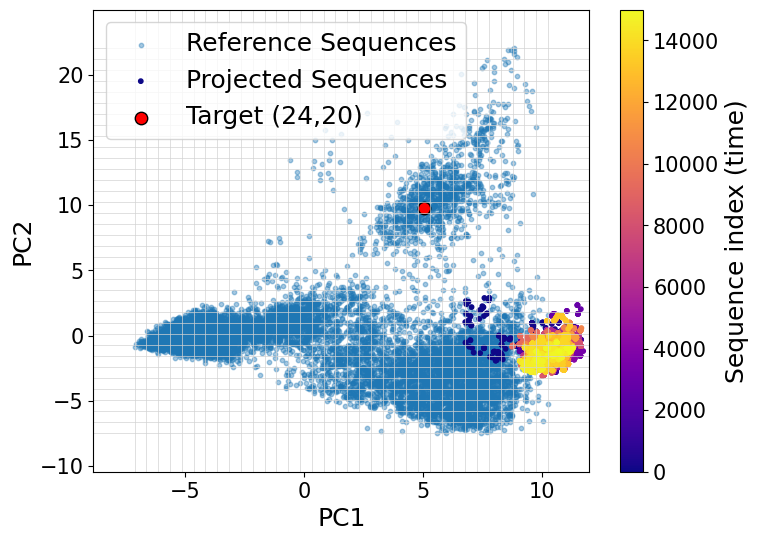

(14502, 65)
(14502,)
(970, 63)

Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA6_PCA_comp_27_5PCA_comp.npy


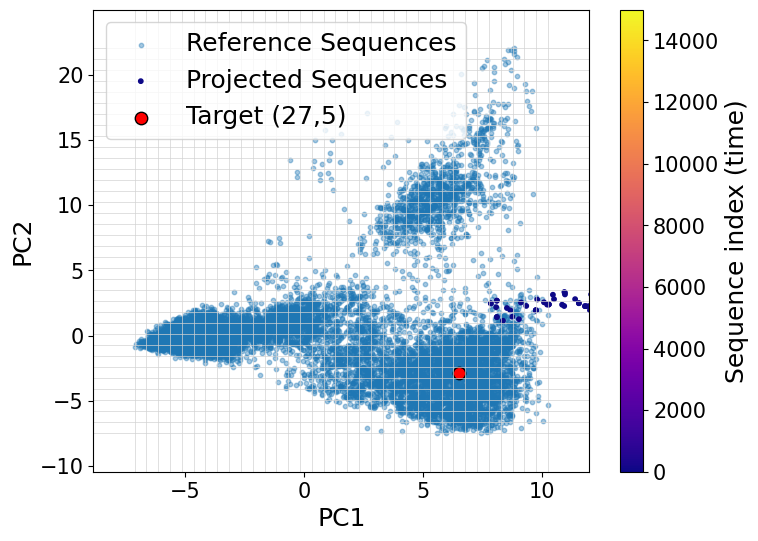

(14502, 65)
(14502,)
(3840, 63)

Processing file: gen_seqs_randinit_Ns15000_b_1_b_PCA6_PCA_comp_8_8PCA_comp.npy


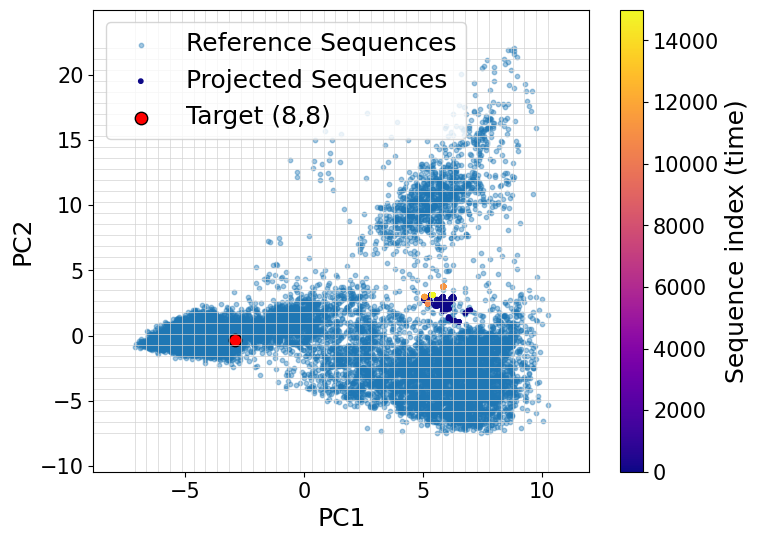

(14502, 65)
(14502,)
(7914, 63)


In [10]:
# ----- Paths -----
generated_dir = 'generated_sequences_2Model_specificPCA_comp'
cwd = os.getcwd()
full_gen_path = os.path.join(cwd, generated_dir)

# ----- Load train sequences -----
family = 'jdoms_bacteria_train2'
file_test_data=r"C:\Users\youss\OneDrive\Bureau\master epfl\MA2\TP4 De los Rios\git_test\PLM-gen-DCA\Attention-DCA-main\CODE\DataAttentionDCA\jdoms\jdoms_bacteria_train2.fasta"

train_sequences = sequences_from_fasta(file_test_data)
train_sequences_num = [letters_to_nums(seq) for seq in train_sequences]

save_path = os.path.join(cwd, 'results', '2Model_PLM_SPECIFIC')
os.makedirs(save_path, exist_ok=True)

# ----- Loop through all .npy files in directory -----
for file in os.listdir(full_gen_path):
    if file.endswith('.npy'):
        beta, beta_PCA=extract_beta_beta_PCA(file)
        print(f"\nProcessing file: {file}")
        
        # Load generated sequences
        file_path = os.path.join(full_gen_path, file)
        gen_sequences = np.load(file_path)
        L=63
        if gen_sequences.shape[1] > L:
            target_coords = gen_sequences[0, -2:]  # Last two columns are PCA coords
            gen_sequences = gen_sequences[:, :-2]  # Remove last 2 cols if they are PCA coords
        else:
            target_coords = None
        # Optional: slice if needed
        # gen_sequences = gen_sequences[Ni:Nf]  # Uncomment if you want to subset

        # Extract target PCA coordinates from filename
        #match = re.findall(r'\d+\.\d+|\d+', file)  # Captures floats or ints
        #if len(match) >= 2:
        #    target_coords = np.array([float(match[-2]), float(match[-1])])
        #else:
        #    print("Warning: Could not extract PCA coords from filename.")
        #    target_coords = None
#
        # Plot PCA projection
        title = f"PCA Projection: {file}"
        plot_projected_pca_time(
            sequences_reference=train_sequences,
            sequences_to_project=gen_sequences,
            title=title,
            Nbins=35,
            target_coords=target_coords,save_path=save_path+"/"+file+".png")
        filename=file
        #plot_frequencies_aa_pos(gen_sequences[1000::200],np.array(train_sequences_num),save_path=save_path,filename=filename,beta=beta,beta_PCA=beta_PCA)
        local_train_sequences=extract_sequences_around_PCA(np.array(train_sequences_num),target_coords,35,7)
        print(local_train_sequences.shape)
        filename=filename+"local_target"
        #plot_frequencies_aa_pos(gen_sequences[1000::200],local_train_sequences,save_path=save_path,filename=filename,beta=beta,beta_PCA=beta_PCA)
        
